# Linear Regression

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Read the file 

In [36]:
df = pd.read_excel("BigMart.xlsx")

In [37]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1,2778.3834
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1,549.2850
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1,1193.1136
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2,1845.5976


In [38]:
df.sample()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
3621,FDO32,6.36,Low Fat,0.120544,Fruits and Vegetables,45.806,OUT046,1997,Small,Tier 1,Supermarket Type1,1165.15


In [39]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [40]:
df.columns

Index(['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility',
       'Item_Type', 'Item_MRP', 'Outlet_Identifier',
       'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Item_Outlet_Sales'],
      dtype='object')

# Check for Dataintegrity

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [42]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


# Feature Engineering

In [43]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [44]:
df["Outlet_Type"].value_counts()

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

<Axes: xlabel='Outlet_Type'>

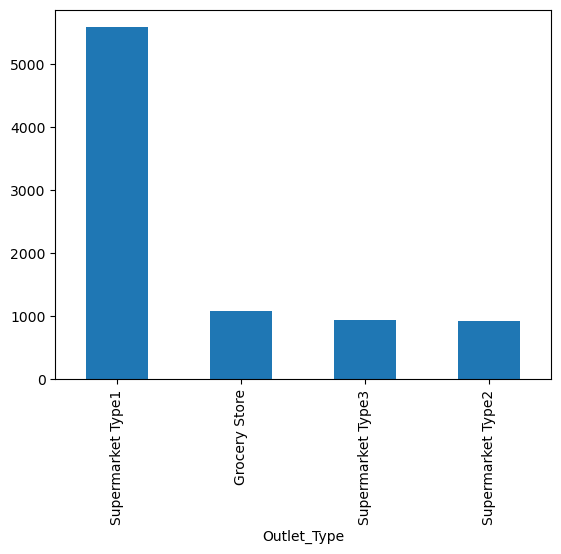

In [45]:
df["Outlet_Type"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

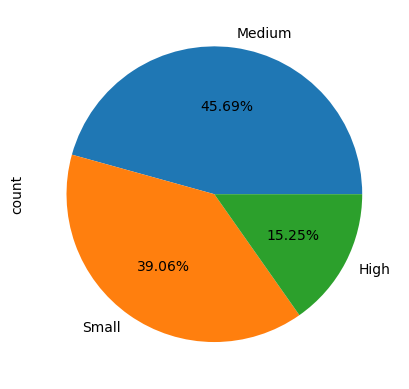

In [46]:
df["Outlet_Size"].value_counts().plot(kind="pie", autopct="%.2f%%")

# Divide  Into features and Responses

In [47]:
features= df.iloc[:,:-1]

In [48]:
response=df.iloc[:,-1]

In [49]:
features

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDA15,9.300,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,DRC01,5.920,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2
2,FDN15,17.500,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store
4,NCD19,8.930,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1
...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,Low Fat,0.056783,Snack Foods,214.5218,OUT013,1987,High,Tier 3,Supermarket Type1
8519,FDS36,8.380,Regular,0.046982,Baking Goods,108.1570,OUT045,2002,NaN,Tier 2,Supermarket Type1
8520,NCJ29,10.600,Low Fat,0.035186,Health and Hygiene,85.1224,OUT035,2004,Small,Tier 2,Supermarket Type1
8521,FDN46,7.210,Regular,0.145221,Snack Foods,103.1332,OUT018,2009,Medium,Tier 3,Supermarket Type2


In [50]:
response

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64

Step 1: Handling Missing values

In [51]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 732.6+ KB


In [52]:
features.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
dtype: int64

# check The % missing values
     

In [53]:
features["Item_Weight"].value_counts()

Item_Weight
12.150    86
17.600    82
13.650    77
11.800    76
15.100    68
          ..
8.920      2
6.520      1
9.420      1
7.685      1
5.400      1
Name: count, Length: 415, dtype: int64

In [54]:
2410/8523

0.2827642848762173

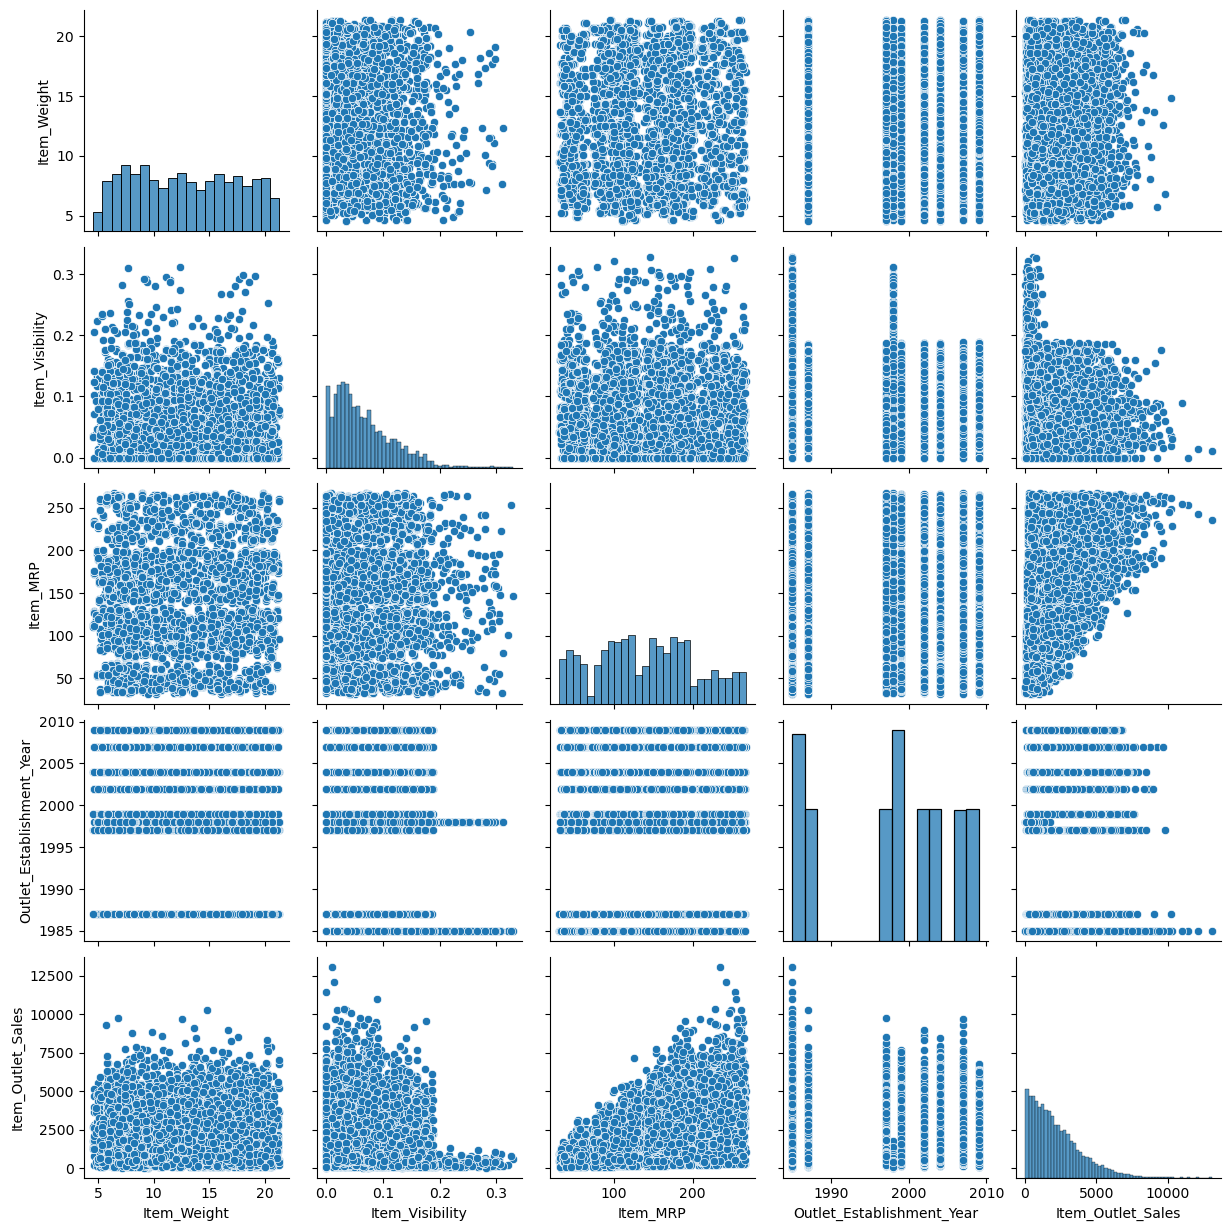

In [55]:
sns.pairplot(df)

# Replacing Missing Values

Using Simple_Imputer

In [56]:
from sklearn.impute import SimpleImputer 

In [57]:
si = SimpleImputer(missing_values=np.nan , strategy="mean")

In [58]:
df[["Item_Weight"]] = si.fit_transform (df[["Item_Weight"]])

In [59]:
df["Item_Weight"].isnull().sum()

np.int64(0)

In [60]:
df["Item_Weight"].value_counts()

Item_Weight
12.857645    1463
12.150000      86
17.600000      82
13.650000      77
11.800000      76
             ... 
5.210000        2
9.420000        1
7.685000        1
5.400000        1
6.520000        1
Name: count, Length: 416, dtype: int64

In [61]:
si = SimpleImputer(missing_values=np.nan , strategy="most_frequent")

In [62]:
df[["Outlet_Size"]] = si.fit_transform (df[["Outlet_Size"]])

In [63]:
df["Outlet_Size"].isnull().sum()

np.int64(0)

In [64]:
df["Outlet_Size"].value_counts()

Outlet_Size
Medium    5203
Small     2388
High       932
Name: count, dtype: int64

# Handling Outliers

In [65]:
df.corr()

ValueError: could not convert string to float: 'FDA15'

<Axes: xlabel='Item_Outlet_Sales', ylabel='Outlet_Size'>

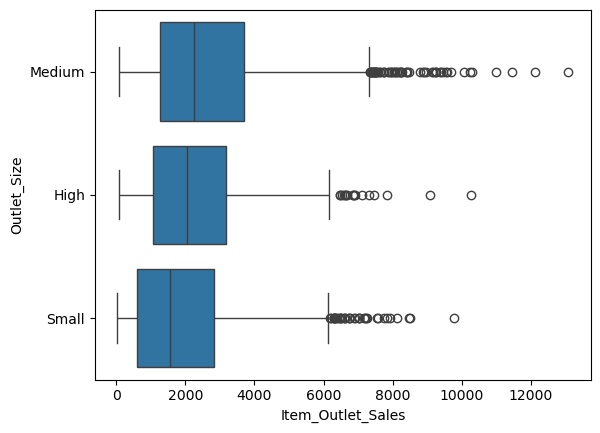

In [66]:
sns.boxplot(data=features ,x=response , y=features["Outlet_Size"])

<Axes: ylabel='Item_Outlet_Sales'>

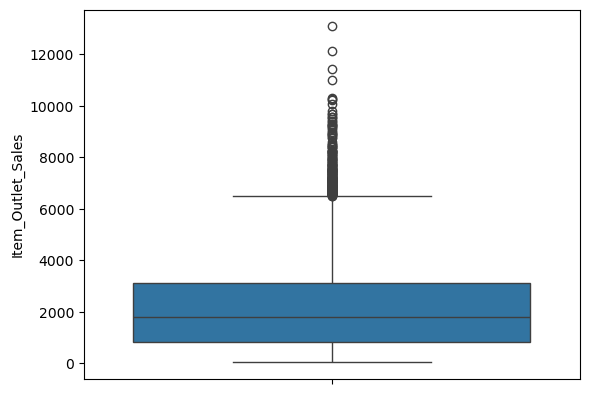

In [67]:
plt.figure()
sns.boxplot(data=features ,y=response)

In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                8523 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                8523 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


# Handling Skewness

# Check Skewness

In [69]:
df.skew(numeric_only=True)

Item_Weight                  0.090561
Item_Visibility              1.167091
Item_MRP                     0.127202
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
dtype: float64

# visualize Skewness

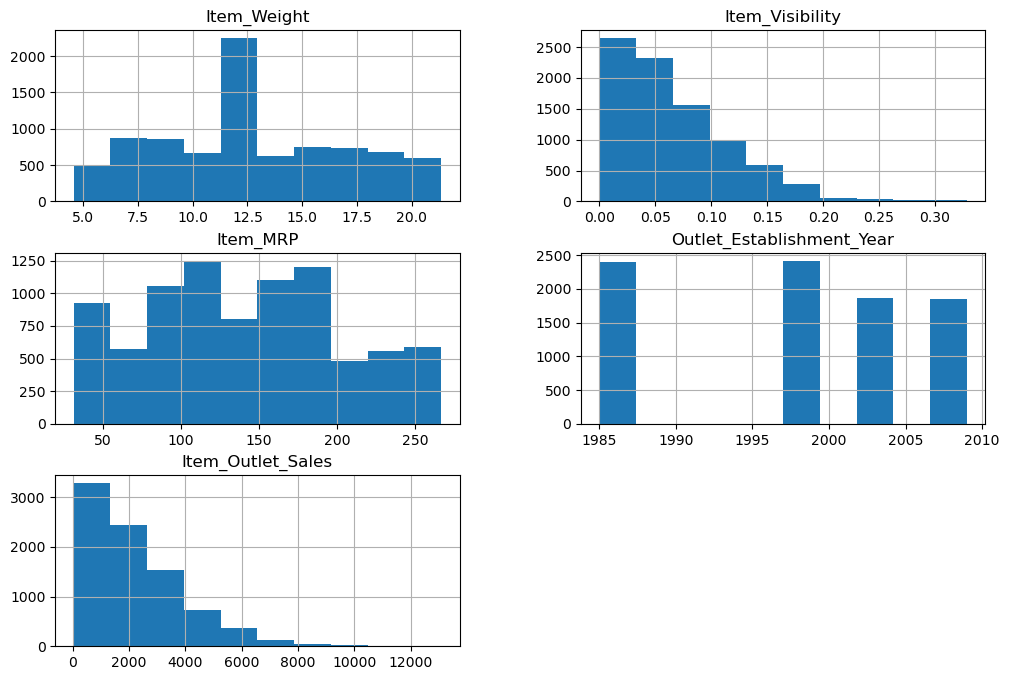

In [70]:
df.hist(figsize=(12,8))
plt.show()

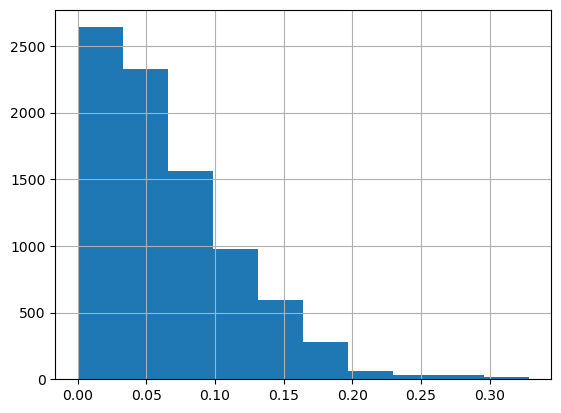

In [71]:
df["Item_Visibility"].hist()
plt.show()

# Remove skewness using transformations

In [72]:
df["Item_Visibility"] = np.log1p(df["Item_Visibility"])

In [73]:
df["Item_Visibility"]

0       0.015920
1       0.019095
2       0.016621
3       0.000000
4       0.000000
          ...   
8518    0.055230
8519    0.045912
8520    0.034581
8521    0.135597
8522    0.043900
Name: Item_Visibility, Length: 8523, dtype: float64

# Square Root Transformation

In [74]:
df["Item_Visibility"] = np.sqrt(df["Item_Visibility"])

In [75]:
df["Item_Visibility"]

0       0.126174
1       0.138184
2       0.128923
3       0.000000
4       0.000000
          ...   
8518    0.235010
8519    0.214271
8520    0.185961
8521    0.368235
8522    0.209524
Name: Item_Visibility, Length: 8523, dtype: float64

# Remove skewness using transformations

In [76]:
df["Item_Visibility"] = np.log1p(df["Item_Visibility"])

In [77]:
df["Item_Visibility"]

0       0.118826
1       0.129434
2       0.121264
3       0.000000
4       0.000000
          ...   
8518    0.211079
8519    0.194144
8520    0.170553
8521    0.313522
8522    0.190227
Name: Item_Visibility, Length: 8523, dtype: float64

In [78]:

df["Item_Visibility"] = np.log1p(df["Item_Visibility"])

print(df.skew(numeric_only=True))

Item_Weight                  0.090561
Item_Visibility             -0.657032
Item_MRP                     0.127202
Outlet_Establishment_Year   -0.396641
Item_Outlet_Sales            1.177531
dtype: float64


In [79]:
num_col=features.select_dtypes(["int64","float64"])

In [80]:
num_col

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
0,9.300,0.016047,249.8092,1999
1,5.920,0.019278,48.2692,2009
2,17.500,0.016760,141.6180,1999
3,19.200,0.000000,182.0950,1998
4,8.930,0.000000,53.8614,1987
...,...,...,...,...
8518,6.865,0.056783,214.5218,1987
8519,8.380,0.046982,108.1570,2002
8520,10.600,0.035186,85.1224,2004
8521,7.210,0.145221,103.1332,2009


In [81]:
from scipy.stats import skew

In [82]:
print(skew(features["Outlet_Size"]))

nan


Item_Weight
nan


<Figure size 640x480 with 0 Axes>

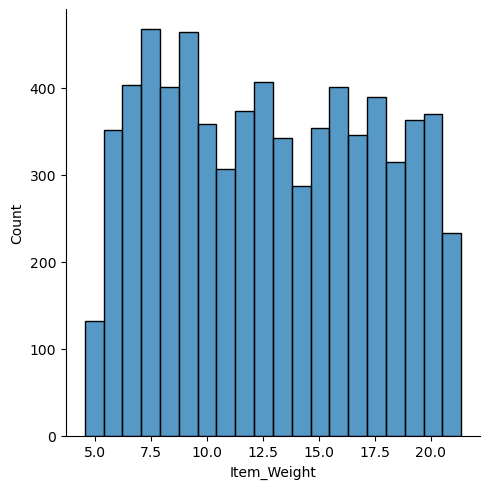

Item_Visibility
1.16688513828559


<Figure size 640x480 with 0 Axes>

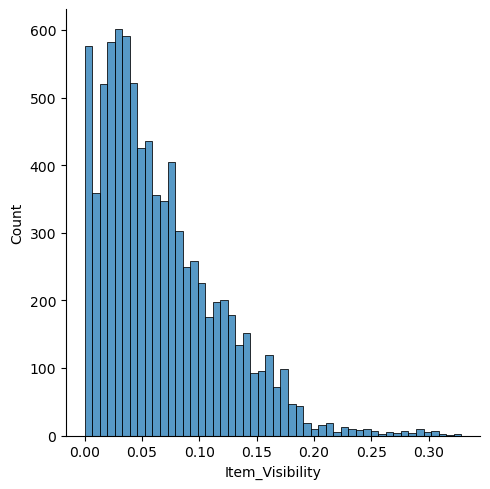

Item_MRP
0.1271798803336854


<Figure size 640x480 with 0 Axes>

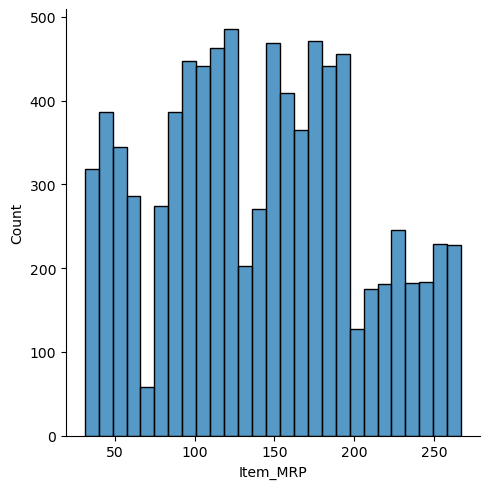

Outlet_Establishment_Year
-0.39657097595805835


<Figure size 640x480 with 0 Axes>

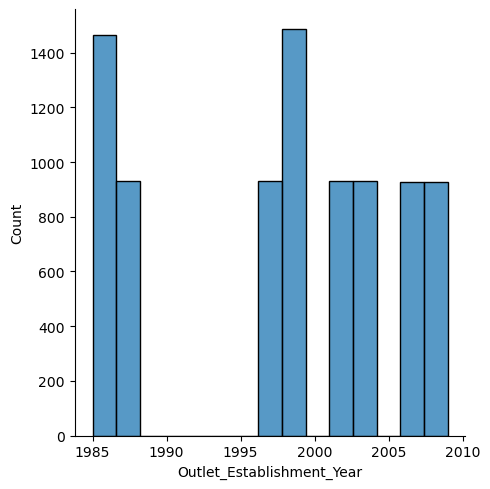

In [83]:
for col in num_col:
    print(col)
    print(skew(features[col]))

    plt.figure()
    sns.displot(features[col])
    plt.show()

In [84]:
np.log(-7)

np.float64(nan)

In [85]:
np.sqrt(-7)

np.float64(nan)

In [86]:
features.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year
count,7060.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867
std,4.643456,0.051598,62.275067,8.371760
min,4.555000,0.000000,31.290000,1985.000000
25%,8.773750,0.026989,93.826500,1987.000000
50%,12.600000,0.053931,143.012800,1999.000000
75%,16.850000,0.094585,185.643700,2004.000000
max,21.350000,0.328391,266.888400,2009.000000


In [89]:
num_col.columns

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')

In [90]:
pd.concat([features[num_col.columns] ,response],axis=1).corr().style.background_gradient()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.014048,0.027141,-0.011588,0.014123
Item_Visibility,-0.014048,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.027141,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,-0.011588,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.014123,-0.128625,0.567574,-0.049135,1.000000


# Encoding

In [93]:
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder

In [94]:
le=LabelEncoder()

In [95]:
le.fit_transform(features[["Item_Visibility"]])

array([ 664,  880,  715, ..., 2302, 7175, 3108])

In [96]:
le.fit_transform(features[["Item_Identifier"]])

array([ 156,    8,  662, ..., 1357,  681,   50])

In [97]:
le.fit_transform(features[["Item_Weight"]])

array([284,  57, 375, ..., 299, 149, 346])

# Check Categorical Column

In [98]:
df.select_dtypes(include="object").columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object')

### Apply Encoding

In [99]:
le = LabelEncoder()

df["Item_Fat_Content"] = le.fit_transform(df["Item_Fat_Content"])
df["Item_Type"] = le.fit_transform(df["Item_Type"])
df["Outlet_Identifier"] = le.fit_transform(df["Outlet_Identifier"])
df["Outlet_Size"] = le.fit_transform(df["Outlet_Size"])
df["Outlet_Location_Type"] = le.fit_transform(df["Outlet_Location_Type"])
df["Outlet_Type"] = le.fit_transform(df["Outlet_Type"])

In [100]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,1,0.112280,4,249.8092,9,1999,1,0,1,3735.1380
1,DRC01,5.920,2,0.121716,14,48.2692,3,2009,1,2,2,443.4228
2,FDN15,17.500,1,0.114457,10,141.6180,9,1999,1,0,1,2097.2700
3,FDX07,19.200,2,0.000000,6,182.0950,0,1998,1,2,0,732.3800
4,NCD19,8.930,1,0.000000,9,53.8614,1,1987,0,2,1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,1,0.191512,13,214.5218,1,1987,0,2,1,2778.3834
8519,FDS36,8.380,2,0.177430,0,108.1570,7,2002,1,1,1,549.2850
8520,NCJ29,10.600,1,0.157476,8,85.1224,6,2004,2,1,1,1193.1136
8521,FDN46,7.210,2,0.272712,13,103.1332,3,2009,1,2,2,1845.5976


In [101]:
x = df.iloc[ :, :1]
y = df.iloc[ :, -2]

# Divide Into train _test_and_split

In [102]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x, y,     test_size=0.2, random_state=1)

# Model_Evaluation

In [103]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [104]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.300,1,0.112280,4,249.8092,9,1999,1,0,1,3735.1380
1,DRC01,5.920,2,0.121716,14,48.2692,3,2009,1,2,2,443.4228
2,FDN15,17.500,1,0.114457,10,141.6180,9,1999,1,0,1,2097.2700
3,FDX07,19.200,2,0.000000,6,182.0950,0,1998,1,2,0,732.3800
4,NCD19,8.930,1,0.000000,9,53.8614,1,1987,0,2,1,994.7052
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,FDF22,6.865,1,0.191512,13,214.5218,1,1987,0,2,1,2778.3834
8519,FDS36,8.380,2,0.177430,0,108.1570,7,2002,1,1,1,549.2850
8520,NCJ29,10.600,1,0.157476,8,85.1224,6,2004,2,1,1,1193.1136
8521,FDN46,7.210,2,0.272712,13,103.1332,3,2009,1,2,2,1845.5976


#### You can encode all text columns automatically

In [105]:
df = pd.get_dummies(df, drop_first=True)

In [106]:
df

,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,...,Item_Identifier_NCZ05,Item_Identifier_NCZ06,Item_Identifier_NCZ17,Item_Identifier_NCZ18,Item_Identifier_NCZ29,Item_Identifier_NCZ30,Item_Identifier_NCZ41,Item_Identifier_NCZ42,Item_Identifier_NCZ53,Item_Identifier_NCZ54
0,9.300,1,0.112280,4,249.8092,9,1999,1,0,1,...,False,False,False,False,False,False,False,False,False,False
1,5.920,2,0.121716,14,48.2692,3,2009,1,2,2,...,False,False,False,False,False,False,False,False,False,False
2,17.500,1,0.114457,10,141.6180,9,1999,1,0,1,...,False,False,False,False,False,False,False,False,False,False
3,19.200,2,0.000000,6,182.0950,0,1998,1,2,0,...,False,False,False,False,False,False,False,False,False,False
4,8.930,1,0.000000,9,53.8614,1,1987,0,2,1,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8518,6.865,1,0.191512,13,214.5218,1,1987,0,2,1,...,False,False,False,False,False,False,False,False,False,False
8519,8.380,2,0.177430,0,108.1570,7,2002,1,1,1,...,False,False,False,False,False,False,False,False,False,False
8520,10.600,1,0.157476,8,85.1224,6,2004,2,1,1,...,False,False,False,False,False,False,False,False,False,False
8521,7.210,2,0.272712,13,103.1332,3,2009,1,2,2,...,False,False,False,False,False,False,False,False,False,False


#### Check which columns are still text

In [107]:
df.select_dtypes(include='object').columns

Index([], dtype='object')

#### One Hot Encoding

In [108]:
df = pd.get_dummies(df, drop_first=True)

In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Columns: 1569 entries, Item_Weight to Item_Identifier_NCZ54
dtypes: bool(1558), float64(4), int64(7)
memory usage: 13.4 MB


#### split data correctly

In [110]:
x = df.drop("Item_Outlet_Sales", axis=1)
y = df["Item_Outlet_Sales"]

#### Divide into train test and split

In [111]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y, test_size=0.2, random_state=1)

### Linear Regression

In [112]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()

linreg.fit(xtrain, ytrain)

yp = linreg.predict(xtest)

print(yp)

[ 110.79558899 1855.05963813 4284.36347071 ... 2474.82528901 2302.49860706
 1470.53739727]


In [113]:
df.dtypes

Item_Weight              float64
Item_Fat_Content           int64
Item_Visibility          float64
Item_Type                  int64
Item_MRP                 float64
                          ...   
Item_Identifier_NCZ30       bool
Item_Identifier_NCZ41       bool
Item_Identifier_NCZ42       bool
Item_Identifier_NCZ53       bool
Item_Identifier_NCZ54       bool
Length: 1569, dtype: object

### Linreg

##### Separate X and Y

#### Assuming Item_Outlet_Sales is your target column:

In [114]:
x = df.drop("Item_Outlet_Sales", axis=1)

In [115]:
y = df["Item_Outlet_Sales"]

#### Train-Test Split

In [116]:
from sklearn.model_selection import train_test_split

xtrain, xtest, ytrain, ytest = train_test_split(x, y,test_size=0.2,random_state=1)

#### Import and Train Linear Regression Model

In [117]:
from sklearn.linear_model import LinearRegression

# Create object
linreg = LinearRegression()

# Train model
linreg.fit(xtrain, ytrain)

LinearRegression()

#### Prediction

In [118]:
yp = linreg.predict(xtest)

print(yp)

[ 110.79558899 1855.05963813 4284.36347071 ... 2474.82528901 2302.49860706
 1470.53739727]


#### Model Accuracy/ Evaluation

In [119]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
print("R2 Score :", r2_score(ytest, yp))
print("MAE :", mean_absolute_error(ytest, yp))
print("MSE :", mean_squared_error(ytest, yp))
print("RMSE :", np.sqrt(mean_squared_error(ytest, yp)))

R2 Score : 0.3293552681387696
MAE : 1061.1968145362482
MSE : 1988004.4791108954
RMSE : 1409.9661269374153


### Multi_linreg

#### slope

In [120]:
linreg.coef_

array([   -4.54189679,    32.61317656, -1400.01114689, ...,
        2184.82321999,   678.70934496,  1370.79742958])

In [121]:
linreg.intercept_

np.float64(4842.665806696669)

#### Predictions

In [122]:
df.columns

Index(['Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       ...
       'Item_Identifier_NCZ05', 'Item_Identifier_NCZ06',
       'Item_Identifier_NCZ17', 'Item_Identifier_NCZ18',
       'Item_Identifier_NCZ29', 'Item_Identifier_NCZ30',
       'Item_Identifier_NCZ41', 'Item_Identifier_NCZ42',
       'Item_Identifier_NCZ53', 'Item_Identifier_NCZ54'],
      dtype='object', length=1569)

In [123]:
from sklearn.linear_model import LinearRegression

# Create model
mlr = LinearRegression()

# Train model
mlr.fit(xtrain, ytrain)

LinearRegression()

In [124]:
yp = mlr.predict(xtest)

print(yp)

[ 110.79558899 1855.05963813 4284.36347071 ... 2474.82528901 2302.49860706
 1470.53739727]


### Prediction

In [125]:
yp = mlr.predict(xtest)

print(yp)

[ 110.79558899 1855.05963813 4284.36347071 ... 2474.82528901 2302.49860706
 1470.53739727]


#### Model Evaluation

In [126]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score :", r2_score(ytest, yp))
print("MAE :", mean_absolute_error(ytest, yp))
print("MSE :", mean_squared_error(ytest, yp))
print("RMSE :", np.sqrt(mean_squared_error(ytest, yp)))

R2 Score : 0.3293552681387696
MAE : 1061.1968145362482
MSE : 1988004.4791108954
RMSE : 1409.9661269374153


In [127]:
df.isna().sum()

Item_Weight              0
Item_Fat_Content         0
Item_Visibility          0
Item_Type                0
Item_MRP                 0
                        ..
Item_Identifier_NCZ30    0
Item_Identifier_NCZ41    0
Item_Identifier_NCZ42    0
Item_Identifier_NCZ53    0
Item_Identifier_NCZ54    0
Length: 1569, dtype: int64